In [1]:
import os
os.chdir("../")

In [28]:
import pandas as pd
data= pd.read_csv("artifacts/data_ingestion/data.csv")

In [29]:
data.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [30]:
round((data.isnull().sum() / data.shape[0]) * 100, 2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

In [31]:
data.drop(columns=['Cabin'], inplace=True)

In [ ]:
#imputing missing values for age with mean
data['Age'].fillna(data['Age'].mean(), inplace=True)
#imputing embarked missinf with 'S' 
data['Embarked'].fillna('S', inplace=True)
# changing the datatype of survived, pclass, sex, embarked to category
data['Survived'] = data['Survived'].astype('category')
data['Pclass'] = data['Pclass'].astype('category')
data['Sex']=data['Sex'].astype('category')
data['Embarked']=data['Embarked'].astype('category')

C:\Users\hp\AppData\Local\Temp\ipykernel_14884\1301383836.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(), inplace=True)


<Axes: xlabel='Survived', ylabel='count'>

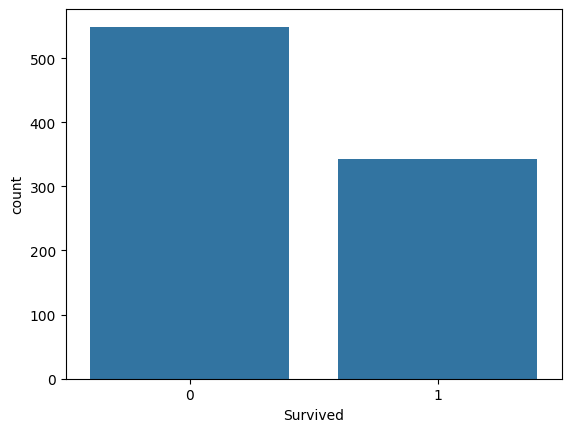

In [36]:
#univariate analysis on Survived
import seaborn as sns
sns.countplot(x='Survived', data=data)

In [61]:
from dataclasses import dataclass
from pathlib import Path

@dataclass
class DataTransformationConfig:
    root_dir:Path
    data_dir: Path

In [62]:
from src.data_line.constants import *
from src.data_line.utils.common import read_yaml, create_directories   


In [63]:
class ConfigurationManager:
    def __init__(self, config_filepath=CONFIG_FILE_PATH,
                 params_filepath=PARAMS_FILE_PATH,
                 schema_filepath=SCHEMA_FILE_PATH):
        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)
        self.schema = read_yaml(schema_filepath)

        create_directories([self.config.artifacts_root])

    def get_data_transformation_config(self) -> DataTransformationConfig:
        config=self.config.data_transformation
        create_directories([config.root_dir])
        data_transformation_config=DataTransformationConfig(
            root_dir=config.root_dir,
            data_dir=config.data_dir
        )
        return data_transformation_config    

In [64]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from src.data_line import logger


In [65]:
class DataTransformation:

    def __init__(self, config: DataTransformationConfig):
        self.config = config


    def train_test_split_save_data(self):
        try:
            data = pd.read_csv(self.config.data_dir)

            # 🔹 Apply transformations BEFORE split
            data = self.apply_transformations(data)

            train, test = train_test_split(
                data, test_size=0.2, random_state=42
            )

            train.to_csv(os.path.join(self.config.root_dir, "train.csv"), index=False)
            test.to_csv(os.path.join(self.config.root_dir, "test.csv"), index=False)

            logger.info("Data transformation completed successfully.")

        except Exception as e:
            logger.error(f"Error during data transformation: {e}")
            raise e


    def apply_transformations(self, data):
        # Impute Age
        data['Age'] = data['Age'].fillna(data['Age'].mean())

        # Impute Embarked
        data['Embarked'] = data['Embarked'].fillna('S')

        # Convert types
        data['Survived'] = data['Survived'].astype('category')
        data['Pclass'] = data['Pclass'].astype('category')
        data['Sex'] = data['Sex'].astype('category')
        data['Embarked'] = data['Embarked'].astype('category')

        return data


In [66]:
try:
    config_manager = ConfigurationManager()
    data_transformation_config = config_manager.get_data_transformation_config()

    data_transformer = DataTransformation(config=data_transformation_config)
    data_transformer.train_test_split_save_data()
except Exception as e:
    logger.error(f"Error in main execution: {e}")    

2026-02-15 00:54:33,553 - INFO - common - yaml file: config\config.yaml loaded successfully
2026-02-15 00:54:33,555 - INFO - common - yaml file: params.yaml loaded successfully
2026-02-15 00:54:33,561 - INFO - common - yaml file: schema.yaml loaded successfully
2026-02-15 00:54:33,563 - INFO - common - created directory at: artifacts
2026-02-15 00:54:33,563 - INFO - common - created directory at: artifacts/data_transformation
2026-02-15 00:54:33,642 - INFO - 3457575143 - Data transformation completed successfully.
